# Model Training and Fine-Tuning

This notebook demonstrates the full workflow for training a YOLO-based car detection model for parking environments.

The workflow includes:
- Installing required libraries
- Uploading custom datasets
- Loading COCO data
- Merging datasets
- Preparing data in YOLO format
- Training with fine-tuning
- Evaluating the model
- Running inference on new images

In [1]:
!pip install ultralytics fiftyone -q

import os, json, shutil, random, yaml
from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO
import torch

print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 169.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 16.2 MB/s eta 0:

## Upload Custom Datasets

In this step, two custom datasets are uploaded as ZIP files and extracted into the Colab environment.

These datasets contain parking-related images and annotations that will later be merged with COCO data to improve model performance.

In [2]:
from google.colab import files
import zipfile


print('dataset1.zip')
u = files.upload()
with zipfile.ZipFile(list(u.keys())[0]) as z:
    z.extractall('/content/dataset1')

print('dataset2.zip')
u = files.upload()
with zipfile.ZipFile(list(u.keys())[0]) as z:
    z.extractall('/content/dataset2')



dataset1.zip


Saving train.zip to train.zip
dataset2.zip


Saving 24.zip to 24.zip


## Load COCO Dataset

Here, the COCO 2017 dataset is loaded using FiftyOne.

Only the **car** class is selected, since the project focuses on vehicle detection.  
COCO is used to provide general object detection knowledge and improve dataset diversity.

In [3]:
import fiftyone.zoo as foz

dataset = foz.load_zoo_dataset(
    'coco-2017',
    split='train',
    classes=['car'],
    max_samples=104
)
print(f'{len(dataset)}')

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/coco-2017/train' if necessary


INFO:fiftyone.utils.coco:Downloading annotations to '/root/fiftyone/coco-2017/tmp-download/annotations_trainval2017.zip'


 100% |██████|    1.9Gb/1.9Gb [6.4s elapsed, 0s remaining, 336.1Mb/s]      


INFO:eta.core.utils: 100% |██████|    1.9Gb/1.9Gb [6.4s elapsed, 0s remaining, 336.1Mb/s]      


...

 100% |█████████████████| 104/104 [263.8ms elapsed, 0s remaining, 394.3 samples/s]     


INFO:eta.core.utils: 100% |█████████████████| 104/104 [263.8ms elapsed, 0s remaining, 394.3 samples/s]     


Dataset 'coco-2017-train-104' created


INFO:fiftyone.zoo.datasets:Dataset 'coco-2017-train-104' created


104


## Merge Custom Datasets with COCO

This step combines:
- Custom parking datasets
- COCO car samples

The purpose of merging datasets is to:
- Increase data diversity
- Reduce top-view bias
- Improve generalization
- Prepare a stronger dataset for fine-tuning

In [4]:
random.seed(42)
MERGED = '/content/merged'
all_samples = []  # (img_path, label_path)


for ds in ['/content/dataset1/train', '/content/dataset2/24']:
    ann_file = f'{ds}/_annotations.coco.json'
    if not os.path.exists(ann_file):
        continue
    with open(ann_file) as f:
        coco = json.load(f)

    car_ids  = {c['id'] for c in coco['categories'] if c['name'] == 'car'}
    images   = {img['id']: img for img in coco['images']}
    img_anns = defaultdict(list)
    for ann in coco['annotations']:
        if ann['category_id'] in car_ids:
            img_anns[ann['image_id']].append(ann)

    for img_id, info in images.items():
        img_path = f"{ds}/{info['file_name']}"
        if not os.path.exists(img_path) or not img_anns[img_id]:
            continue
        W, H = info['width'], info['height']
        lbl = f"/tmp/{img_id}.txt"
        with open(lbl, 'w') as lf:
            for ann in img_anns[img_id]:
                x, y, w, h = [float(v) for v in ann['bbox']]
                lf.write(f"0 {(x+w/2)/W:.6f} {(y+h/2)/H:.6f} {w/W:.6f} {h/H:.6f}\n")
        all_samples.append((img_path, lbl))

for sample in dataset:
    cars = [d for d in sample.ground_truth.detections if d.label == 'car']
    if not cars:
        continue
    lbl = f"/tmp/coco_{Path(sample.filepath).stem}.txt"
    with open(lbl, 'w') as lf:
        for d in cars:
            x, y, w, h = d.bounding_box
            lf.write(f"0 {x+w/2:.6f} {y+h/2:.6f} {w:.6f} {h:.6f}\n")
    all_samples.append((sample.filepath, lbl))

print(f'{len(all_samples)}')


random.shuffle(all_samples)
n  = len(all_samples)
t  = int(n * 0.8)
v  = int(n * 0.1)
splits = {'train': all_samples[:t], 'valid': all_samples[t:t+v], 'test': all_samples[t+v:]}

for s, items in splits.items():
    img_dir = f'{MERGED}/{s}/images'
    lbl_dir = f'{MERGED}/{s}/labels'
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)
    for i, (img, lbl) in enumerate(items):
        name = f'{s}_{i:04d}'
        shutil.copy(img, f'{img_dir}/{name}{Path(img).suffix}')
        shutil.copy(lbl, f'{lbl_dir}/{name}.txt')
    print(f'  {s}: {len(items)} ')

# ── data.yaml ─────────────────────────────────────────────
yaml_path = f'{MERGED}/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump({'path': MERGED, 'train': 'train/images', 'val': 'valid/images',
               'test': 'test/images', 'nc': 1, 'names': ['car']}, f)

203
  train: 162 
  valid: 20 
  test: 21 


## Train the YOLO Model

In this step, a pretrained YOLO model (`yolo26s.pt`) is used as the starting point.

This is an example of **transfer learning**, where we reuse a model that already learned general object features.

Fine-tuning is then applied using the merged parking dataset.

### Key training settings:
- **epochs = 100**: number of training cycles
- **imgsz = 640**: input image size
- **batch = 16**: number of samples per batch
- **freeze = 5**: freeze early layers to preserve general features
- **lr0 = 0.0001**: low learning rate for stable fine-tuning

### Data augmentation:
- Vertical flip
- Horizontal flip
- Mosaic
- Rotation
- Brightness variation

These augmentations improve robustness and generalization.

In [5]:
model = YOLO('yolo26s.pt')

model.train(
    data     = yaml_path,
    epochs   = 100,
    imgsz    = 640,
    batch    = 16,
    freeze   = 5,
    lr0      = 0.0001,
    patience = 20,
    device   = 0,
    project  = '/content/training',
    name     = 'parking',
    exist_ok = True,
    flipud   = 0.5,
    fliplr   = 0.5,
    mosaic   = 1.0,
    degrees  = 15,
    hsv_v    = 0.4,
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=5, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=parking, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fe7082c15e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

## Evaluate the Trained Model

After training, the best saved model is loaded and evaluated on the **test split**.

The main evaluation metrics are:

- **mAP@50**: overall detection performance at IoU = 0.5
- **Precision**: how many predicted detections are correct
- **Recall**: how many real cars were successfully detected

These metrics are used to measure the quality of the trained model and compare it with previous versions.

In [6]:
best  = '/content/training/parking/weights/best.pt'
model = YOLO(best)
m     = model.val(data=yaml_path, split='test')

print(f'mAP@50:    {m.box.map50:.3f}')
print(f'Precision: {m.box.mp:.3f}')
print(f'Recall:    {m.box.mr:.3f}')

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4962.2±3015.4 MB/s, size: 97.0 KB)
val: Scanning /content/merged/test/labels... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21 2.4Kit/s 0.0s
val: New cache created: /content/merged/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.7it/s 0.8s
                   all         21       1714      0.708      0.797      0.732      0.509
Speed: 1.2ms preprocess, 26.4ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/runs/detect/val
mAP@50:    0.732
Precision: 0.708
Recall:    0.797


## Test the Model on a New Image

This step uploads a new test image and runs inference using the trained model.

The model prediction is saved and displayed, and the number of detected cars is printed.

Saving IMG_0829.jpg to IMG_0829.jpg

image 1/1 /content/IMG_0829.jpg: 384x640 12 cars, 19.6ms
Speed: 1.0ms preprocess, 19.6ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/test/run


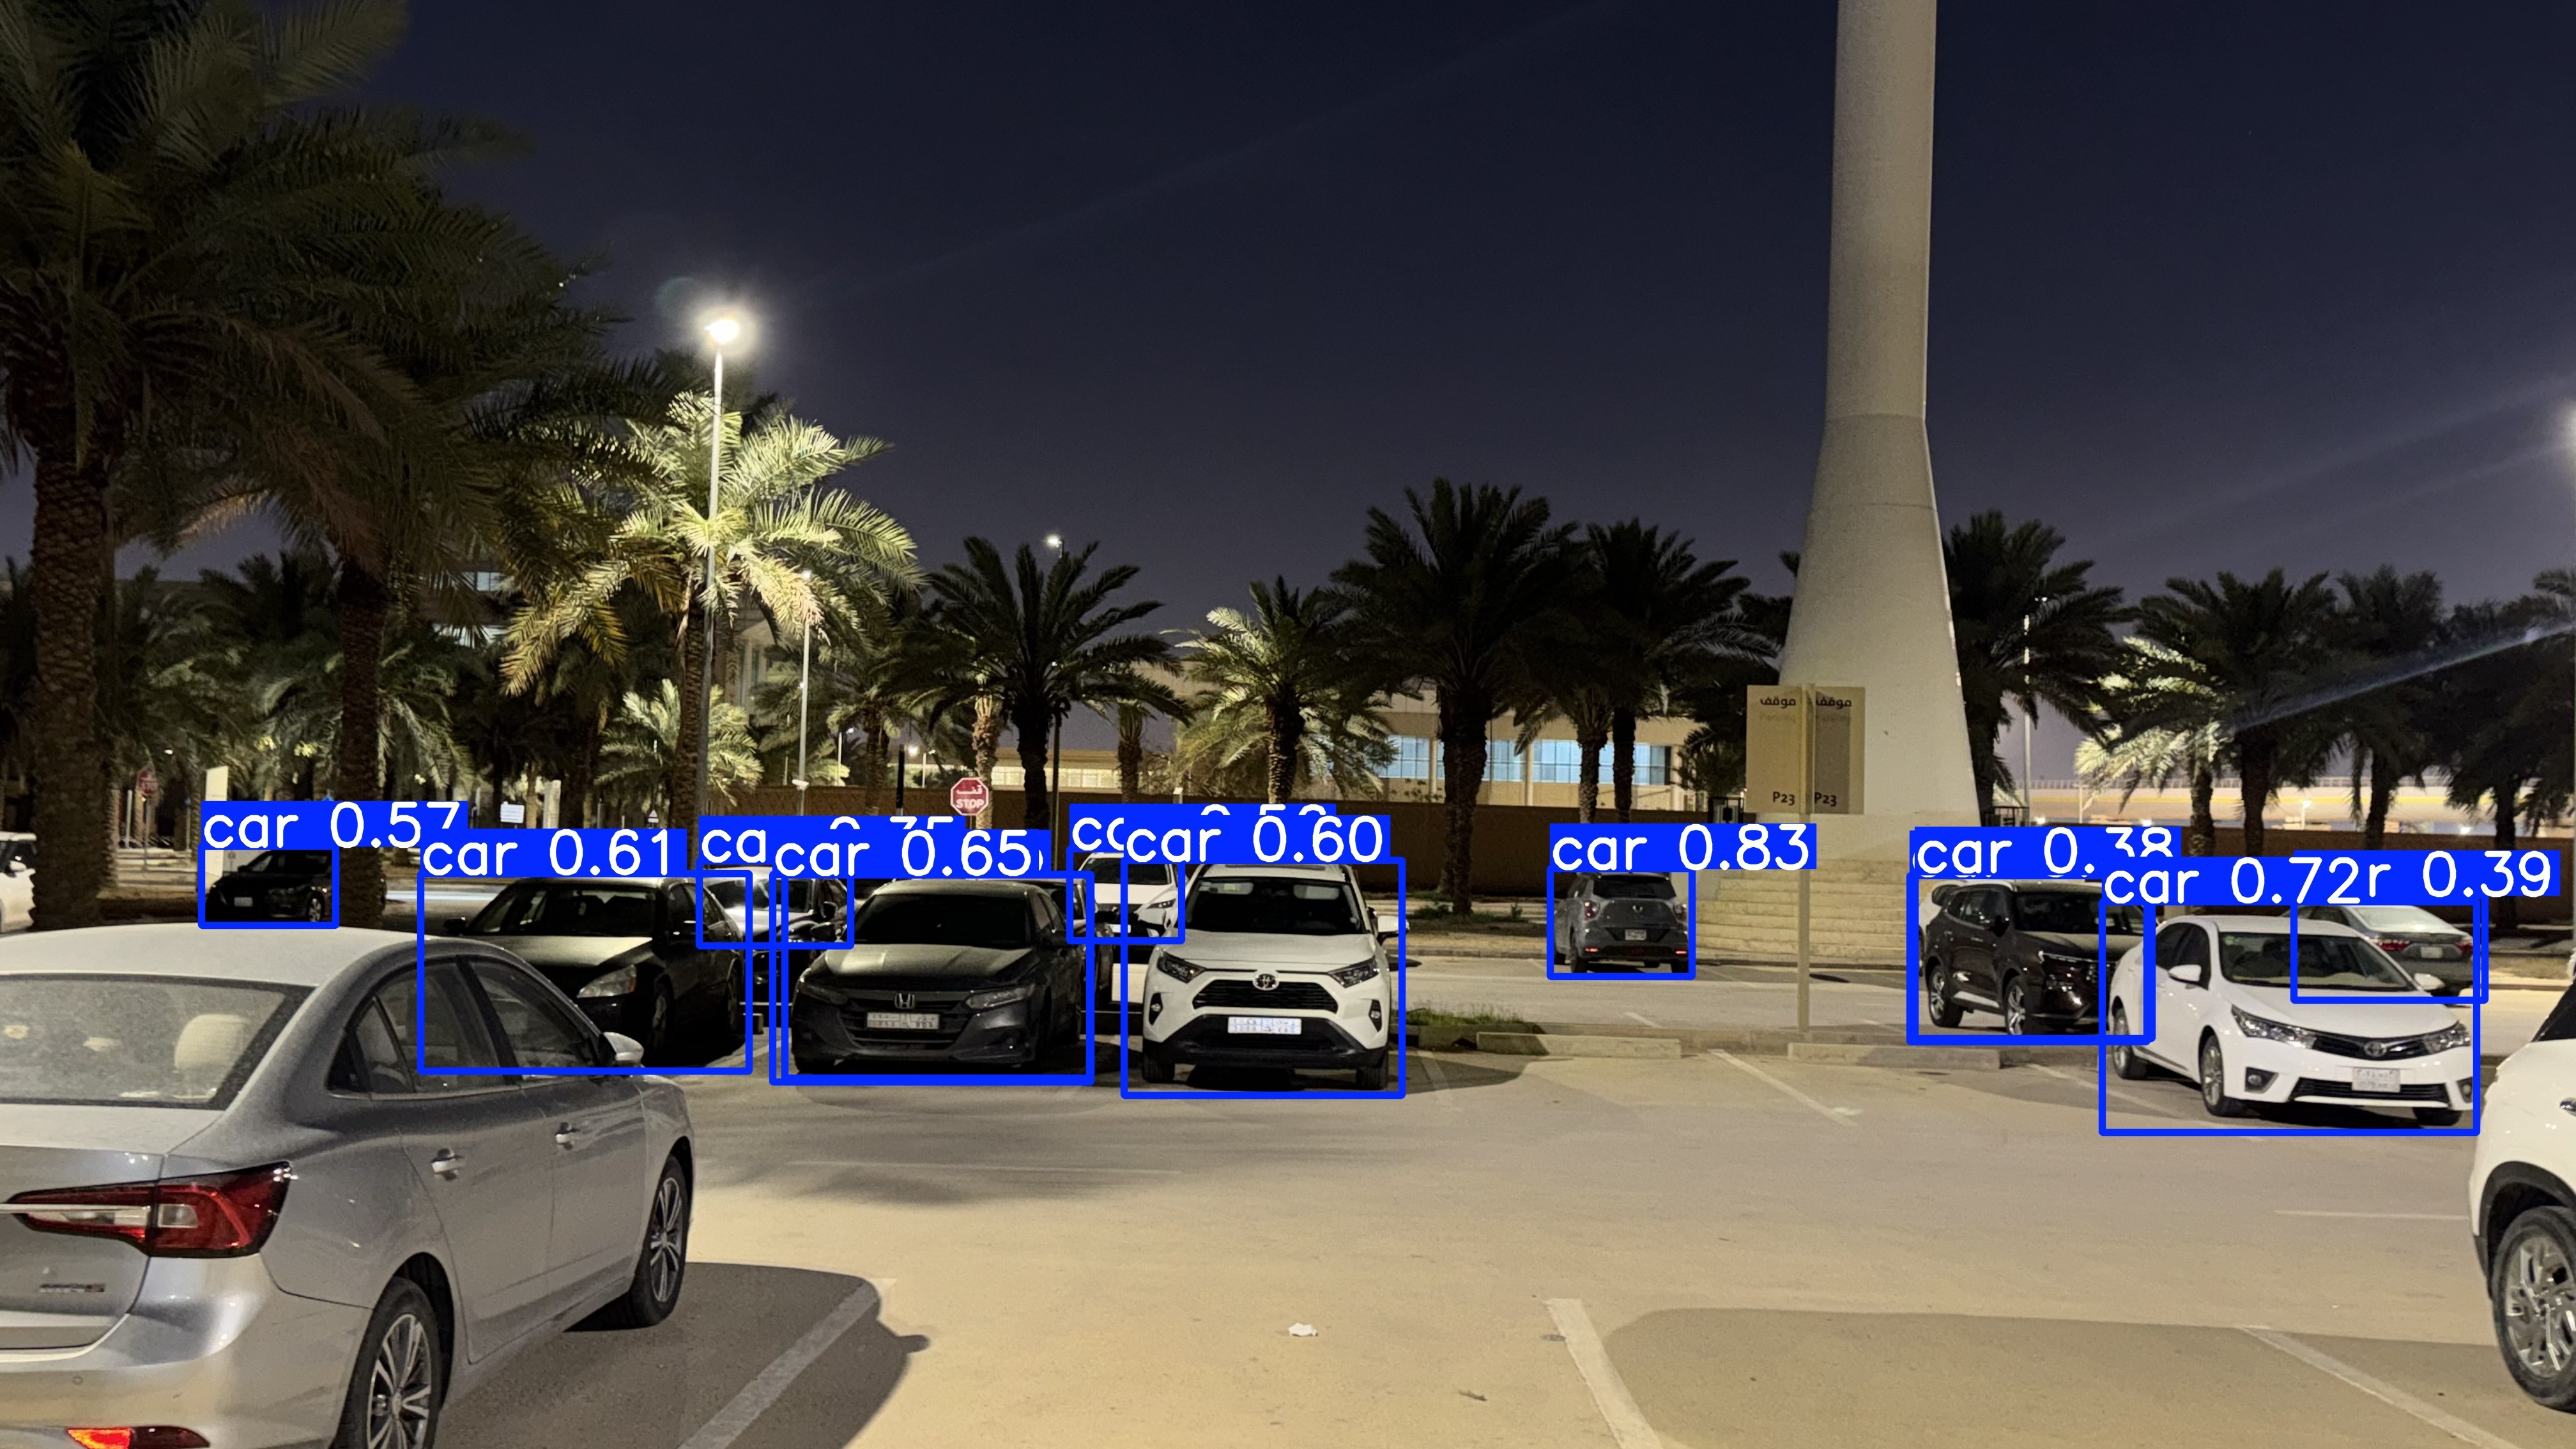

cars: 12


In [11]:
!pip install ultralytics fiftyone -q
from google.colab import files
from IPython.display import Image, display
from ultralytics import YOLO
import os, json, shutil, random, yaml
u = files.upload()
img = list(u.keys())[0]

best  = '/content/training/parking/weights/best.pt'
model = YOLO(best)
results = model.predict(img, conf=0.25, save=True,
                        project='/content/test', name='run', exist_ok=True)
display(Image(f'/content/test/run/{img}'))
print(f'cars: {len(results[0].boxes)}')

## Check Model File Size

This step lists all `.pt` files in the working directory and prints their sizes.

It helps verify the saved model files and inspect their storage size.

In [9]:
import os

for f in os.listdir('/content'):
    if f.endswith('.pt'):
        size = os.path.getsize(f'/content/{f}') / (1024*1024)
        print(f'{f}: {size:.1f} MB')

yolo26n.pt: 5.3 MB
yolo26s.pt: 19.5 MB


## Download the Best Model

Finally, the trained best model is downloaded from Colab so it can be reused later for testing, deployment, or comparison with other models.

In [10]:
files.download('/content/training/parking/weights/best.pt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Insight

This notebook demonstrates a complete training pipeline using:
- Transfer learning
- Fine-tuning
- Dataset merging
- Data augmentation
- Evaluation on a test split

The improvements in the final model came mainly from:
- Increasing dataset diversity
- Reducing top-view bias
- Fine-tuning a pretrained YOLO model on parking-specific data